# Customer Segmentation — Unsupervised Learning
### RFM Feature Engineering + K-Means, Agglomerative Clustering, DBSCAN
**Dataset:** Online Retail II (UCI ML Repository)  
**Scope:** UK customers only, CustomerID not null

This notebook fully implements Steps 1–7 of the practical exam.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


## Step 1: Dataset Loading & Exploratory Data Analysis

### 1.1 Load & Filter the Dataset

In [38]:
# Load dataset - use the xlsx or csv version you downloaded
# xlsx has two sheets (Year 2009-2010, Year 2010-2011) - combine both
try:
    sheet1 = pd.read_excel('online_retail_II.xlsx', sheet_name=0)
    sheet2 = pd.read_excel('online_retail_II.xlsx', sheet_name=1)
    df = pd.concat([sheet1, sheet2], ignore_index=True)
except FileNotFoundError:
    # fallback to CSV version (Kaggle mirror is usually a single combined CSV)
    df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

print(df.shape)
df.info()
df.head(10)


(1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [39]:
# Filter UK customers only
df = df[df['Country'] == 'United Kingdom'].copy()
print("After UK filter:", df.shape)

# Drop rows with null CustomerID
before = df.shape[0]
df = df.dropna(subset=['Customer ID'])
print(f"Dropped {before - df.shape[0]} rows with null CustomerID. Remaining: {df.shape[0]}")


After UK filter: (981330, 8)
Dropped 240029 rows with null CustomerID. Remaining: 741301


In [40]:
# Drop returns/cancellations (Quantity <= 0, InvoiceNo starting with 'C')
before = df.shape[0]
df = df[df['Quantity'] > 0]
print(f"Dropped {before - df.shape[0]} rows with Quantity <= 0. Remaining: {df.shape[0]}")

# Drop UnitPrice <= 0
before = df.shape[0]
df = df[df['Price'] > 0]
print(f"Dropped {before - df.shape[0]} rows with UnitPrice <= 0. Remaining: {df.shape[0]}")

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['Price']
df.head()


Dropped 16005 rows with Quantity <= 0. Remaining: 725296
Dropped 46 rows with UnitPrice <= 0. Remaining: 725250


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### 1.2 Univariate Analysis

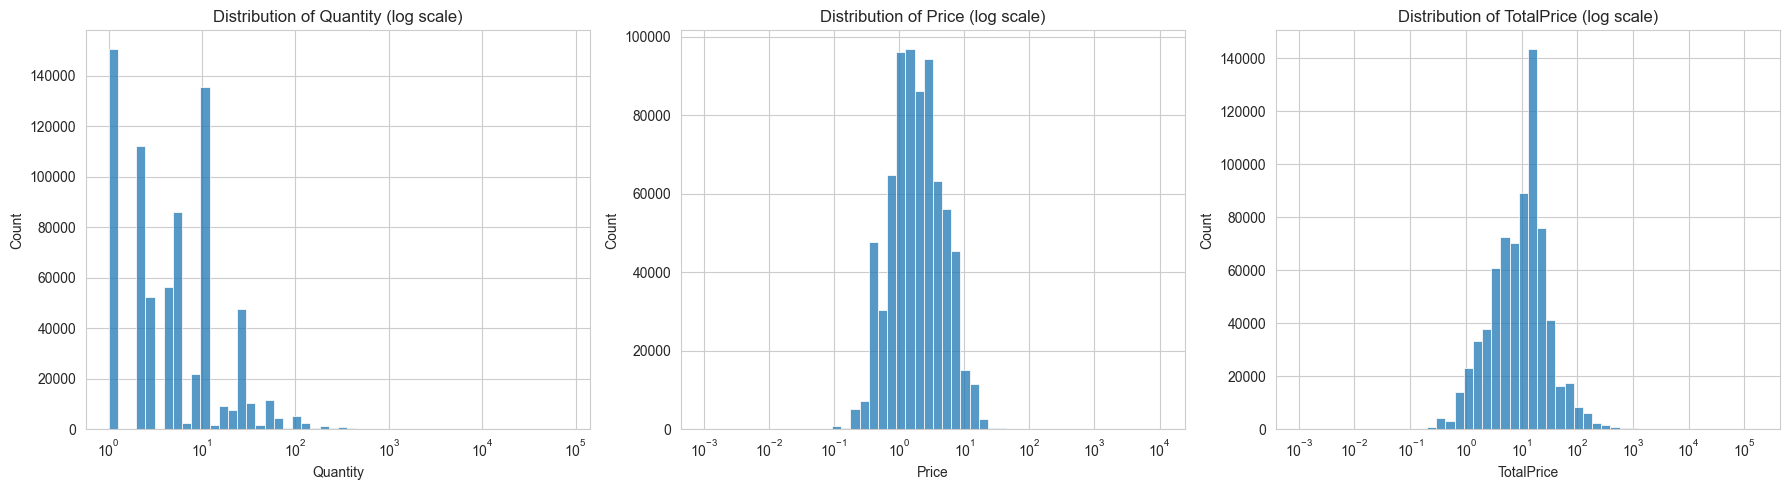

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Quantity', 'Price', 'TotalPrice']):
    sns.histplot(df[col], bins=50, ax=ax, log_scale=True)
    ax.set_title(f'Distribution of {col} (log scale)')
plt.tight_layout()
plt.show()


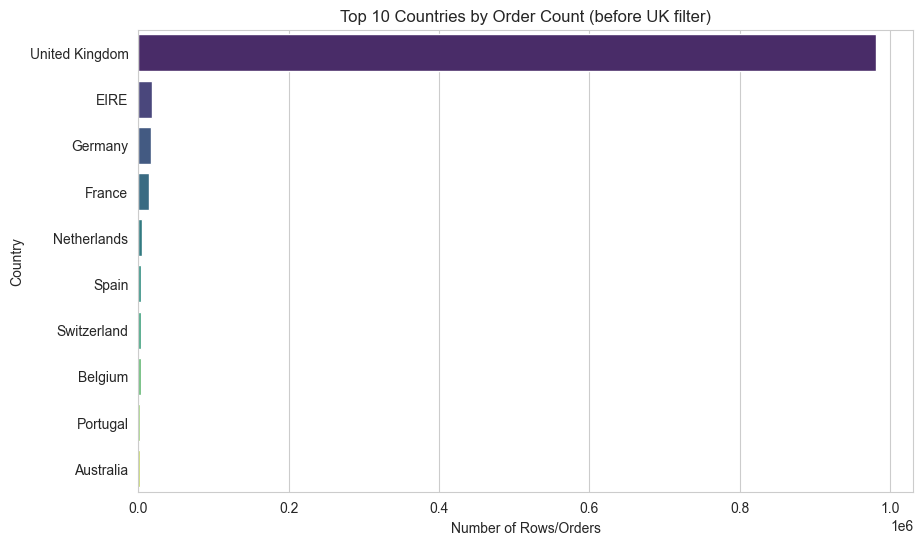

In [42]:
# Top 10 countries by order count BEFORE filtering to UK (reload raw for context)
try:
    raw = pd.concat([pd.read_excel('online_retail_II.xlsx', sheet_name=0),
                      pd.read_excel('online_retail_II.xlsx', sheet_name=1)], ignore_index=True)
except FileNotFoundError:
    raw = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

top10 = raw['Country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title('Top 10 Countries by Order Count (before UK filter)')
plt.xlabel('Number of Rows/Orders')
plt.show()


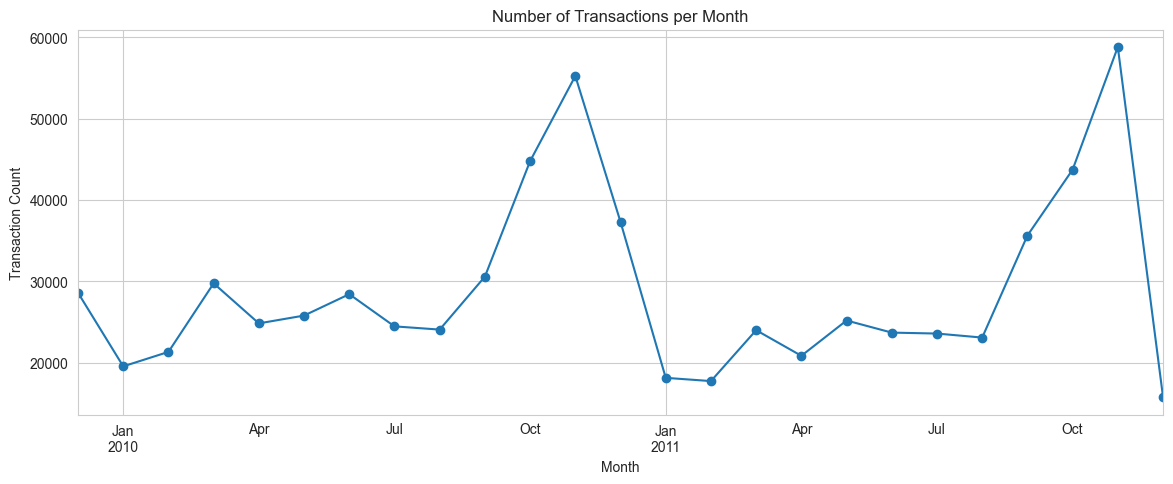

In [43]:
# Transactions per month
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
monthly = df.set_index('InvoiceDate').resample('M').size()
plt.figure(figsize=(14, 5))
monthly.plot(kind='line', marker='o')
plt.title('Number of Transactions per Month')
plt.ylabel('Transaction Count')
plt.xlabel('Month')
plt.show()
# NOTE: Look for a spike around Oct-Nov (pre-Christmas shopping season)


### 1.3 Customer-Level Analysis

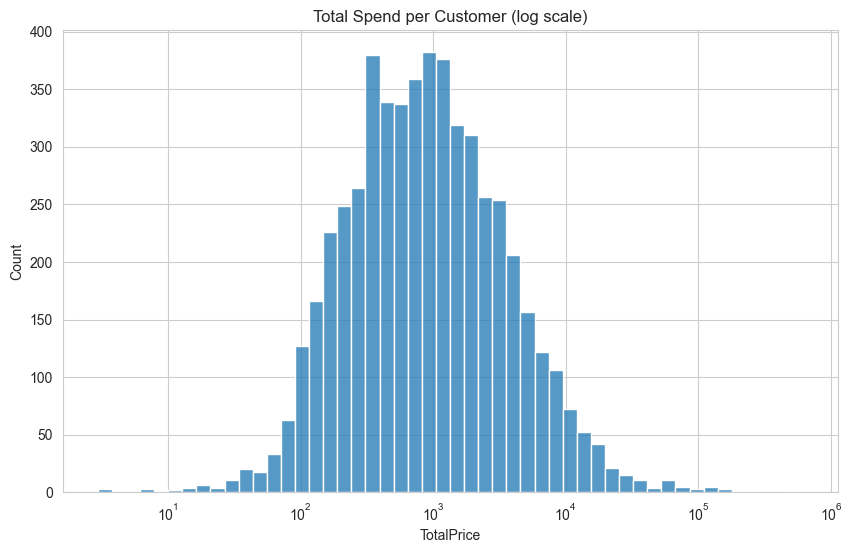

Top 10 highest-frequency buyers:
Customer ID
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
17850.0    155
18102.0    145
13694.0    143
15061.0    127
14527.0    122
Name: Invoice, dtype: int64

Unique customers after cleaning: 5350


In [44]:
# Total spend per customer
cust_spend = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
plt.figure()
sns.histplot(cust_spend, bins=50, log_scale=True)
plt.title('Total Spend per Customer (log scale)')
plt.show()

# Order count per customer
cust_orders = df.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)
print("Top 10 highest-frequency buyers:")
print(cust_orders.head(10))

print(f"\nUnique customers after cleaning: {df['Customer ID'].nunique()}")


In [45]:
# Pareto check: what % of customers drive 80% of revenue?
sorted_spend = cust_spend.sort_values(ascending=False)
cum_pct = sorted_spend.cumsum() / sorted_spend.sum()
n_customers_80pct = (cum_pct <= 0.80).sum() + 1
pct_customers = n_customers_80pct / len(sorted_spend) * 100
print(f"{pct_customers:.1f}% of customers drive 80% of total revenue")
print("This typically confirms the 80/20 Pareto principle in retail data.")


24.3% of customers drive 80% of total revenue
This typically confirms the 80/20 Pareto principle in retail data.


## Step 2: RFM Feature Engineering & Preprocessing

### 2.1 Build the RFM Table

In [46]:
reference_date = pd.Timestamp('2011-12-31')

rfm_df = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm_df.shape)
rfm_df.head(10)


(5350, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346.0,346,12,77556.46
1,12608.0,425,1,415.79
2,12745.0,507,2,723.85
3,12746.0,561,1,254.55
4,12747.0,23,26,9276.54
5,12748.0,21,336,56599.39
6,12749.0,24,9,6897.36
7,12777.0,478,1,519.45
8,12819.0,479,1,540.52
9,12820.0,24,11,2689.52


In [47]:
rfm_df.describe()
# Note the range and skewness -- Monetary and Frequency are typically strongly right-skewed


,Customer ID,Recency,Frequency,Monetary
count,5350.000000,5350.000000,5350.000000,5350.000000
mean,15557.362617,223.546168,6.269346,2751.990190
std,1581.161762,209.973818,11.995550,12080.466564
min,12346.000000,21.000000,1.000000,2.950000
25%,14191.250000,46.000000,1.000000,336.167500
50%,15565.500000,119.000000,3.000000,849.910000
75%,16922.750000,402.000000,7.000000,2214.905000
max,18287.000000,759.000000,336.000000,608821.650000


### 2.2 Handle Outliers

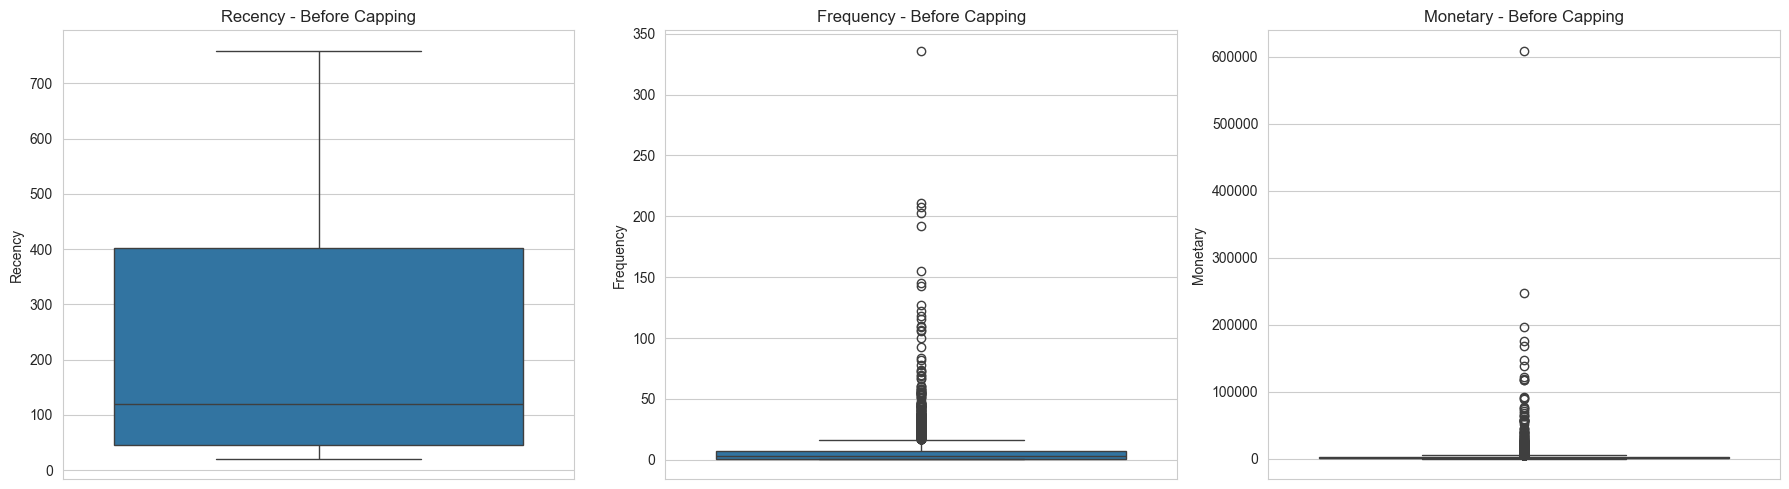

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm_df[col], ax=ax)
    ax.set_title(f'{col} - Before Capping')
plt.tight_layout()
plt.show()


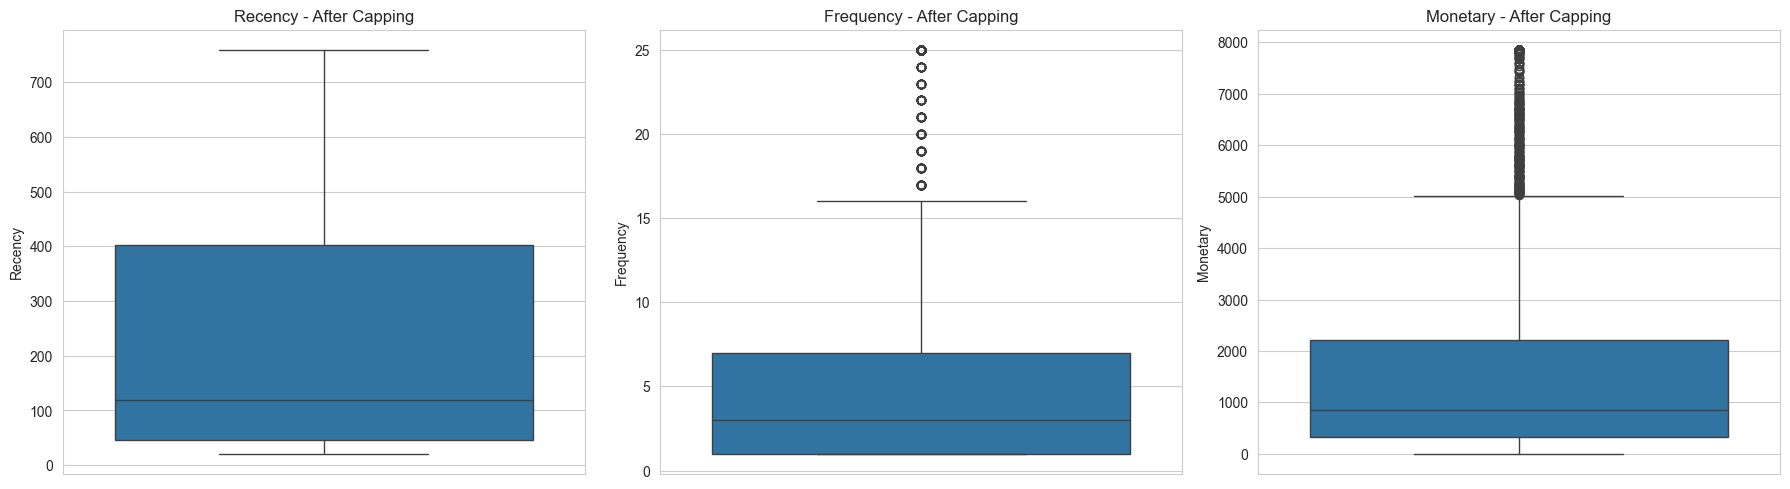

In [49]:
# Cap outliers using IQR method (winsorization, do not drop rows)
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 3 * IQR
    return series.clip(upper=upper)

for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_df[col] = cap_outliers(rfm_df[col])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm_df[col], ax=ax)
    ax.set_title(f'{col} - After Capping')
plt.tight_layout()
plt.show()


### 2.3 Transform Skewed Features

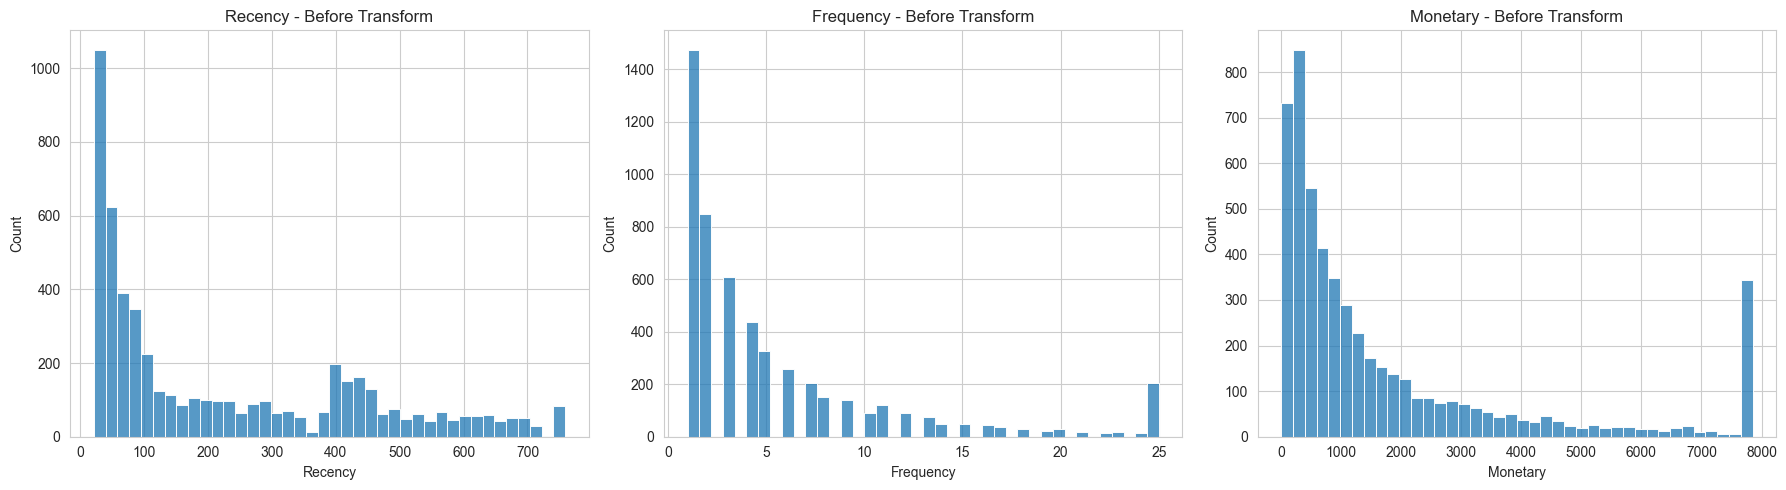

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_df[col], bins=40, ax=ax)
    ax.set_title(f'{col} - Before Transform')
plt.tight_layout()
plt.show()


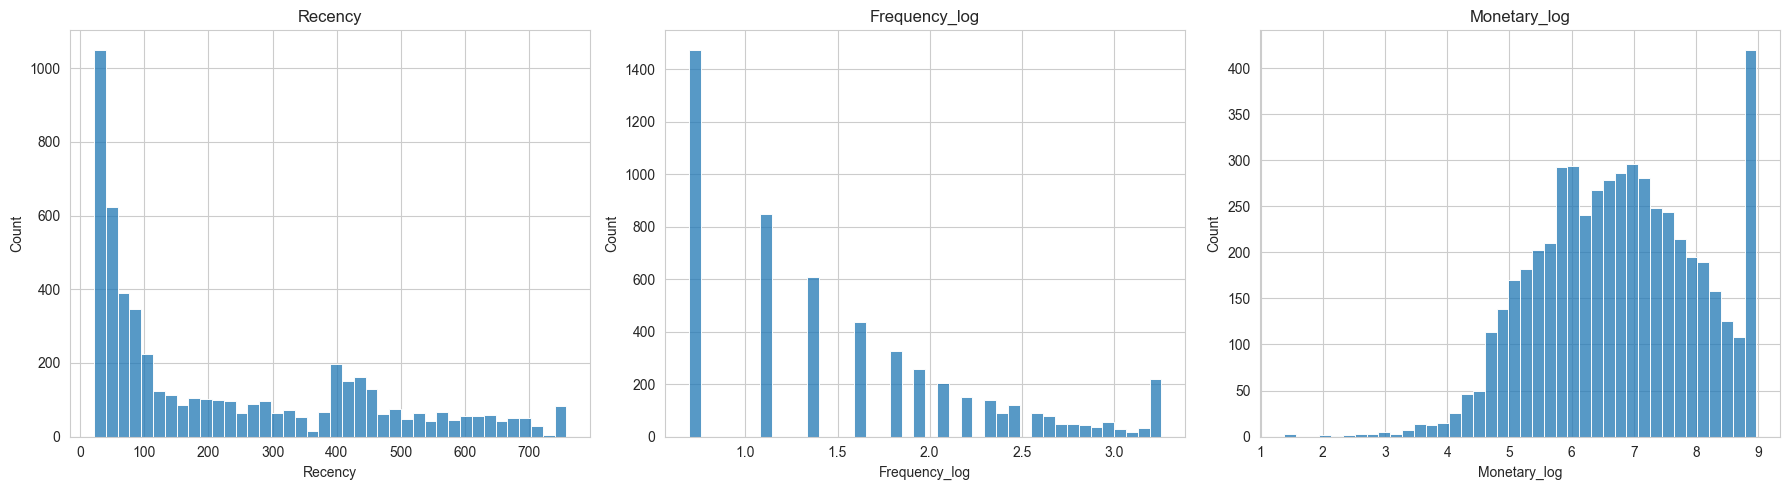

In [51]:
rfm_df['Frequency_log'] = np.log1p(rfm_df['Frequency'])
rfm_df['Monetary_log'] = np.log1p(rfm_df['Monetary'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm_df['Recency'], bins=40, ax=axes[0]); axes[0].set_title('Recency')
sns.histplot(rfm_df['Frequency_log'], bins=40, ax=axes[1]); axes[1].set_title('Frequency_log')
sns.histplot(rfm_df['Monetary_log'], bins=40, ax=axes[2]); axes[2].set_title('Monetary_log')
plt.tight_layout()
plt.show()
# Frequency_log and Monetary_log should now look much more symmetrical/normal


### 2.4 Scale the Features

In [52]:
scaler = StandardScaler()
features = ['Recency', 'Frequency_log', 'Monetary_log']
rfm_scaled = scaler.fit_transform(rfm_df[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features)

print("Mean of scaled features:\n", rfm_scaled.mean())
print("\nStd of scaled features:\n", rfm_scaled.std())


Mean of scaled features:
 Recency         -2.224596e-17
Frequency_log    3.927907e-16
Monetary_log     3.214044e-16
dtype: float64

Std of scaled features:
 Recency          1.000093
Frequency_log    1.000093
Monetary_log     1.000093
dtype: float64


## Step 3: K-Means Clustering

### 3.1 Elbow Method — Find Optimal k

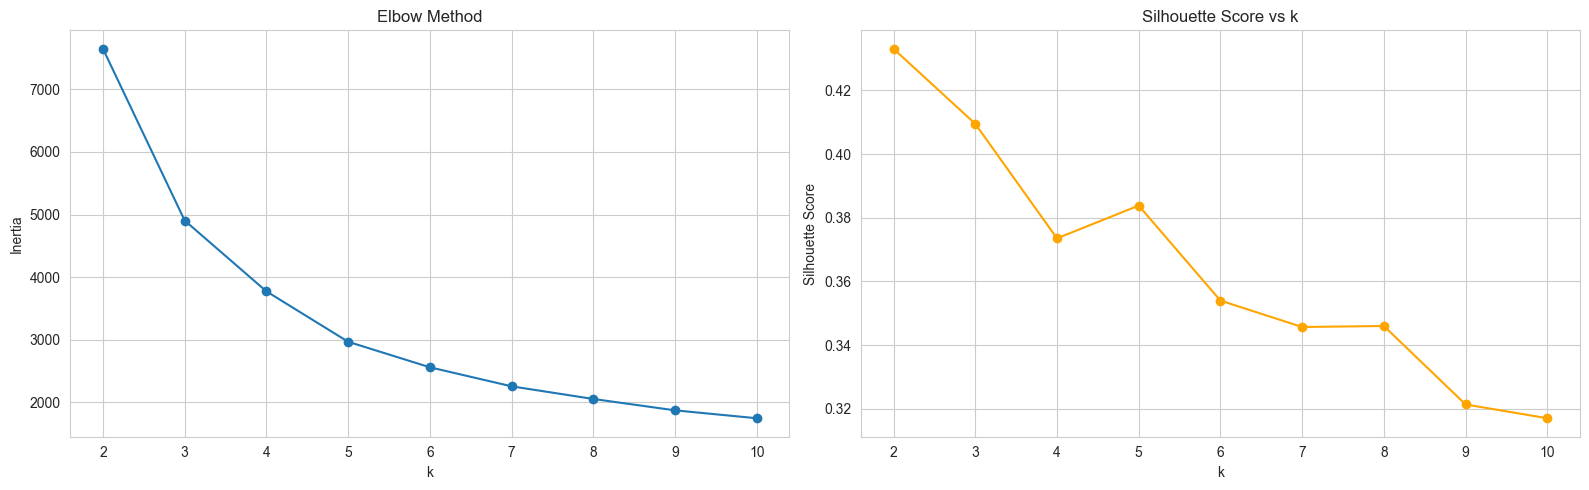

k with highest Silhouette Score: 2


In [53]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score vs k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k_by_silhouette = list(K_range)[np.argmax(sil_scores)]
print(f"k with highest Silhouette Score: {best_k_by_silhouette}")


**Justification (edit after viewing your plots):** Choose `k_optimal` where the elbow curve
bends and the silhouette score is high/locally maximal. Typically k=4 or k=5 balances
interpretability (distinct personas) against diminishing returns in inertia reduction.

In [54]:
k_optimal = best_k_by_silhouette  # <-- adjust manually based on your elbow + silhouette plots
print("Chosen k_optimal:", k_optimal)


Chosen k_optimal: 2


### 3.2 Train Final K-Means Model

In [55]:
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20,
                       max_iter=500, random_state=RANDOM_STATE)
rfm_df['KMeans_Cluster'] = kmeans_final.fit_predict(rfm_scaled)
rfm_df['KMeans_Cluster'].value_counts()


KMeans_Cluster
0    2827
1    2523
Name: count, dtype: int64

### 3.3 Visualise K-Means Clusters

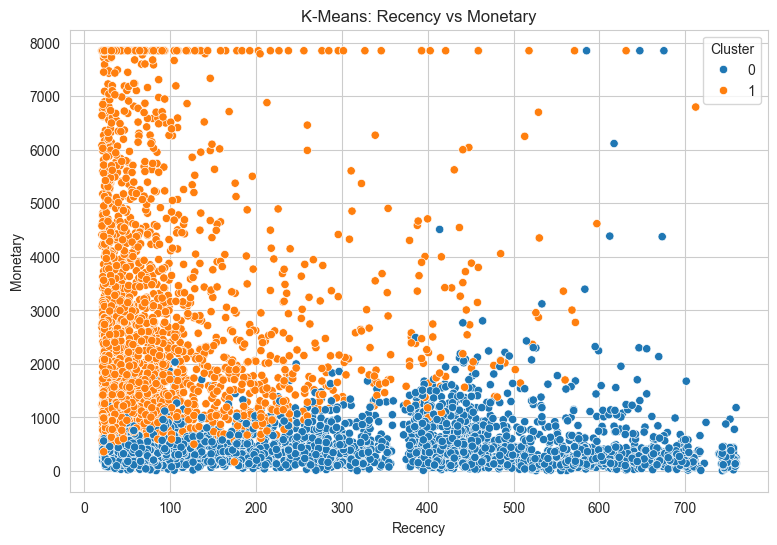

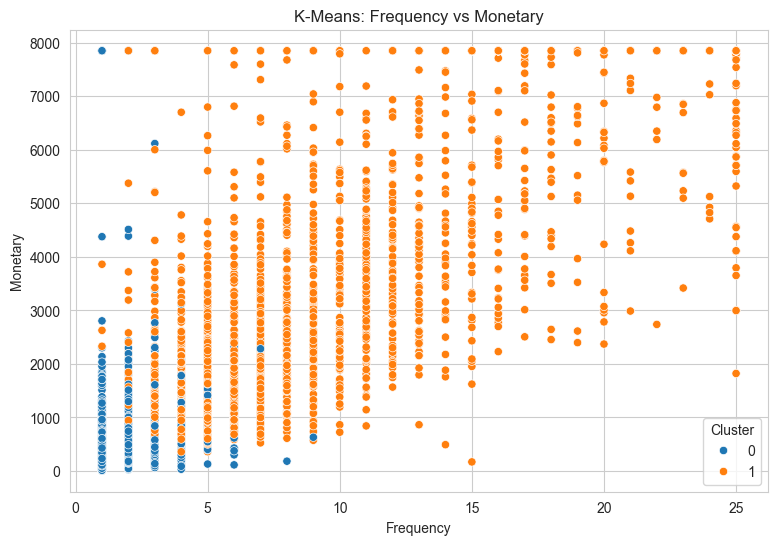

In [56]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='KMeans_Cluster', palette='tab10')
plt.title('K-Means: Recency vs Monetary')
plt.legend(title='Cluster')
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary', hue='KMeans_Cluster', palette='tab10')
plt.title('K-Means: Frequency vs Monetary')
plt.legend(title='Cluster')
plt.show()


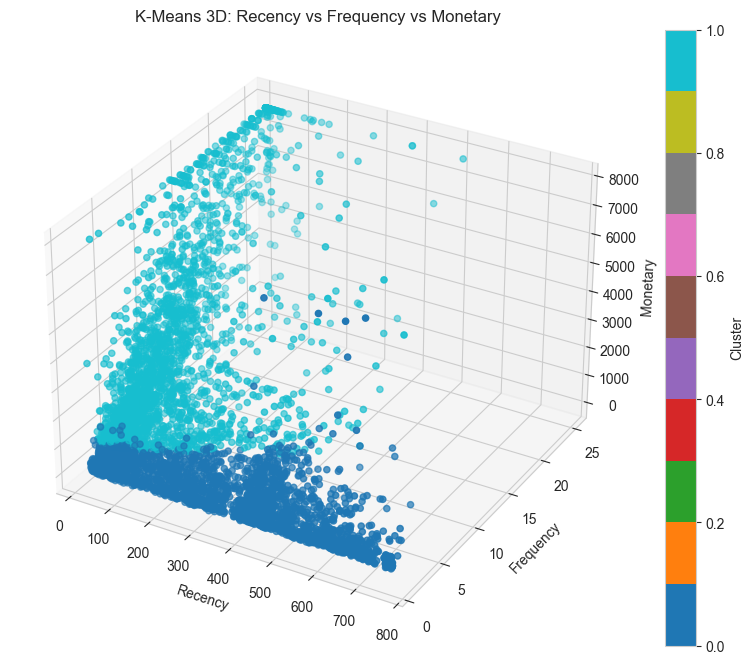

In [57]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(rfm_df['Recency'], rfm_df['Frequency'], rfm_df['Monetary'],
                 c=rfm_df['KMeans_Cluster'], cmap='tab10', s=20)
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('K-Means 3D: Recency vs Frequency vs Monetary')
plt.colorbar(sc, label='Cluster')
plt.show()


### 3.4 Profile the K-Means Clusters

In [58]:
kmeans_profile = rfm_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
kmeans_profile = kmeans_profile.sort_values('Monetary', ascending=False)
kmeans_profile.style.background_gradient(cmap='Blues')


,Recency,Frequency,Monetary
KMeans_Cluster,,,
1,90.485137,9.470472,3219.119474
0,342.298550,1.796250,478.470143


**Persona assignment (edit based on your actual profile table):**
- Lowest Recency + Highest Frequency + Highest Monetary → **Champions**
- Low Recency + moderate Frequency/Monetary → **Loyal Customers**
- High Recency + low Frequency/Monetary → **Hibernating**
- High Recency + moderate spend → **At-Risk Customers**
- Low Frequency + recent first purchase → **New Customers**

## Step 4: Agglomerative Hierarchical Clustering

### 4.1 Dendrogram Analysis

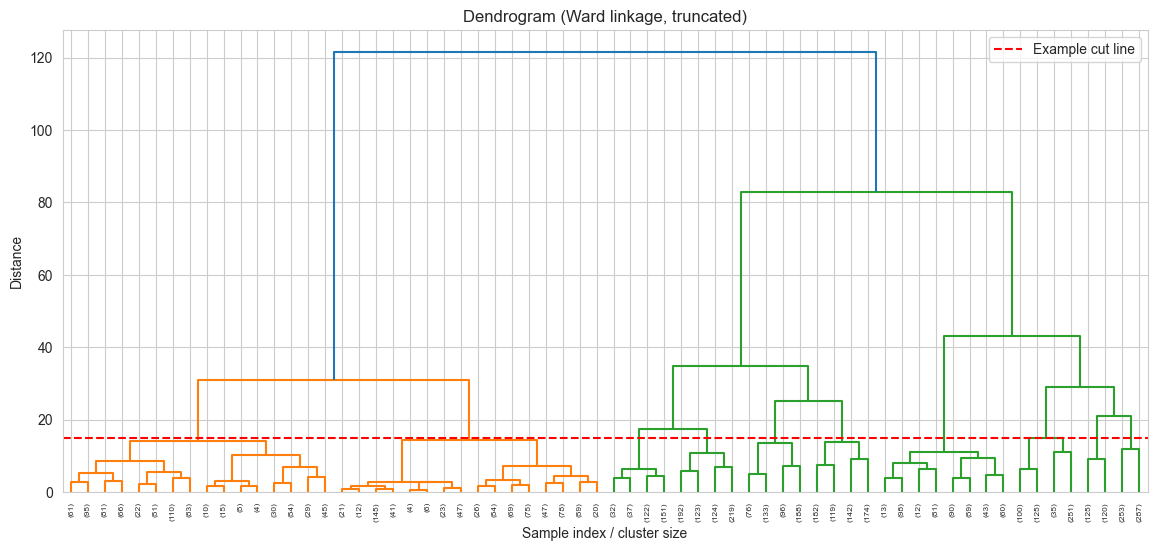

In [59]:
linked = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrogram (Ward linkage, truncated)')
plt.xlabel('Sample index / cluster size')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--', label='Example cut line')  # adjust threshold after viewing
plt.legend()
plt.show()
# Inspect the plot, move the cut line to the distance that gives 3, 4, or 5 clusters


In [60]:
n_chosen = k_optimal  # keep consistent with K-Means for fair comparison, or set manually
print("n_chosen clusters for Agglomerative:", n_chosen)


n_chosen clusters for Agglomerative: 2


### 4.2 Train Agglomerative Model

In [61]:
results_linkage = {}

for link in ['ward', 'complete', 'average']:
    model = AgglomerativeClustering(
        n_clusters=n_chosen,
        linkage=link
    )

    labels = model.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)

    results_linkage[link] = score
    print(f"Linkage={link}: Silhouette Score={score:.4f}")

best_linkage = max(results_linkage, key=results_linkage.get)

agg_final = AgglomerativeClustering(
    n_clusters=n_chosen,
    linkage=best_linkage
)

rfm_df['Agg_Cluster'] = agg_final.fit_predict(rfm_scaled)

Linkage=ward: Silhouette Score=0.3983
Linkage=complete: Silhouette Score=0.1888
Linkage=average: Silhouette Score=0.4521


### 4.3 Visualise & Profile Hierarchical Clusters

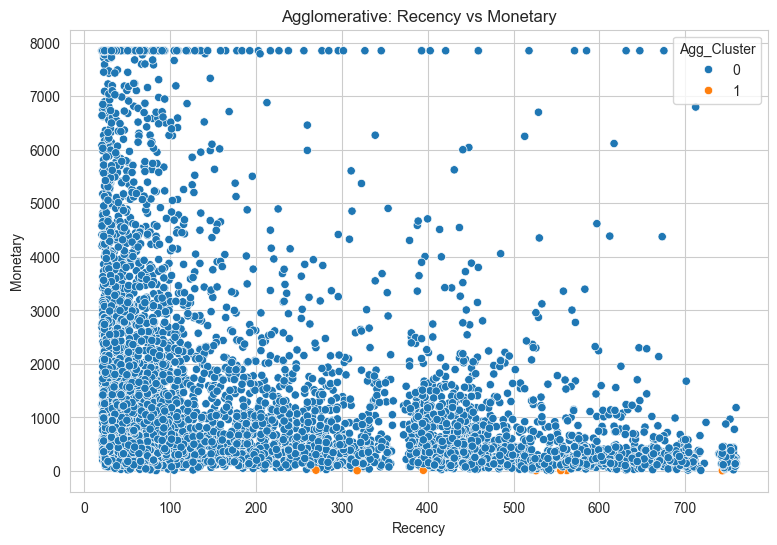

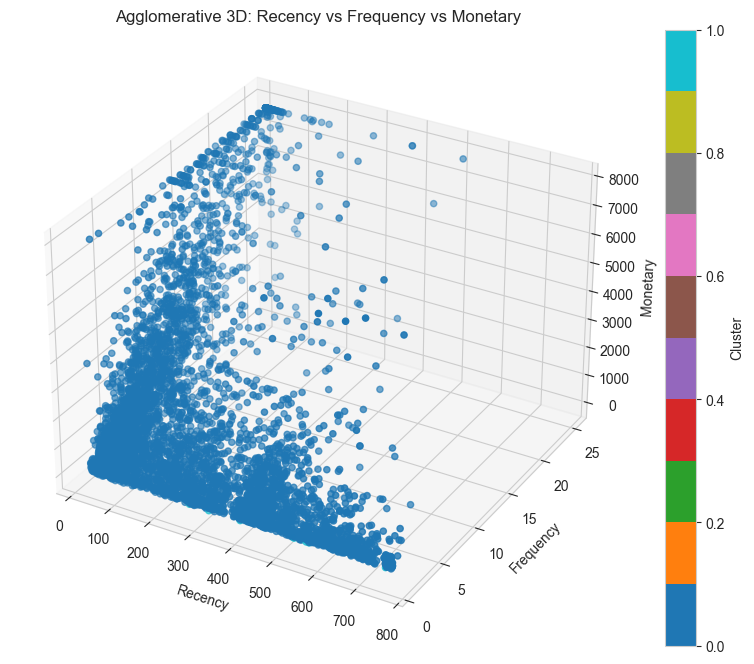

In [62]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='Agg_Cluster', palette='tab10')
plt.title('Agglomerative: Recency vs Monetary')
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(rfm_df['Recency'], rfm_df['Frequency'], rfm_df['Monetary'],
                 c=rfm_df['Agg_Cluster'], cmap='tab10', s=20)
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('Agglomerative 3D: Recency vs Frequency vs Monetary')
plt.colorbar(sc, label='Cluster')
plt.show()


In [63]:
agg_profile = rfm_df.groupby('Agg_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
agg_profile.sort_values('Monetary', ascending=False)


,Recency,Frequency,Monetary
Agg_Cluster,,,
0,223.208497,5.421112,1773.240798
1,481.285714,1.000000,6.848571


**Comparison (edit after inspecting both cross-tabs):** Use `pd.crosstab(rfm_df['KMeans_Cluster'], rfm_df['Agg_Cluster'])`
to see overlap. Ward-linkage Agglomerative usually produces clusters very similar to K-Means since both
minimize within-cluster variance; disagreements typically occur at cluster boundaries for customers with
intermediate RFM values.

In [64]:
pd.crosstab(rfm_df['KMeans_Cluster'], rfm_df['Agg_Cluster'])


Agg_Cluster,0,1
KMeans_Cluster,,
0,2820,7
1,2523,0


## Step 5: DBSCAN Clustering

### 5.1 Tune Epsilon Using k-NN Distance Plot

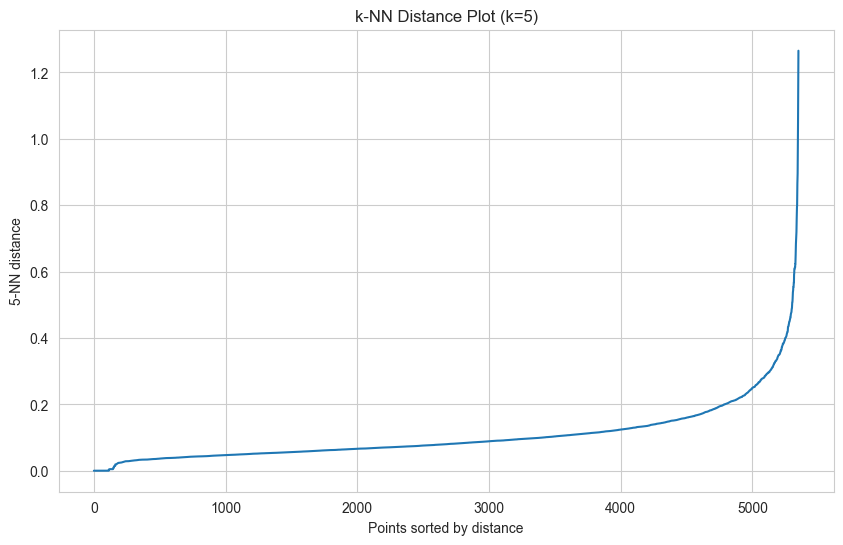

In [65]:
min_pts = 5
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(rfm_scaled)
distances, indices = neighbors_fit.kneighbors(rfm_scaled)

k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f'k-NN Distance Plot (k={min_pts})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_pts}-NN distance')
plt.show()

# Inspect the elbow visually, then set optimal_eps below


In [66]:
optimal_eps = 0.5  # <-- set this to the elbow value you observe in the plot above
print("Chosen eps:", optimal_eps)


Chosen eps: 0.5


### 5.2 Train DBSCAN Model

In [67]:
dbscan = DBSCAN(eps=optimal_eps, min_samples=5, metric='euclidean')
rfm_df['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

n_clusters_db = len(set(rfm_df['DBSCAN_Cluster'])) - (1 if -1 in rfm_df['DBSCAN_Cluster'].values else 0)
n_noise = (rfm_df['DBSCAN_Cluster'] == -1).sum()
pct_noise = n_noise / len(rfm_df) * 100

print(f"Clusters found (excl. noise): {n_clusters_db}")
print(f"Noise points: {n_noise}")
print(f"% classified as noise: {pct_noise:.2f}%")


Clusters found (excl. noise): 2
Noise points: 26
% classified as noise: 0.49%


### 5.3 Tune DBSCAN Hyperparameters

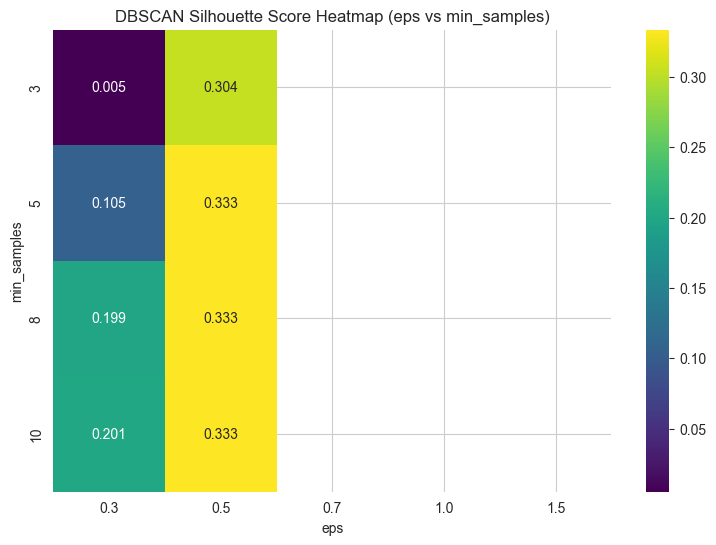

Best combination:
 eps            0.500000
min_samples    5.000000
silhouette     0.333463
Name: 5, dtype: float64


In [68]:
eps_grid = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_grid = [3, 5, 8, 10]
grid_results = []

for eps in eps_grid:
    for ms in min_samples_grid:
        model = DBSCAN(eps=eps, min_samples=ms)
        labels = model.fit_predict(rfm_scaled)
        mask = labels != -1
        if mask.sum() > 1 and len(set(labels[mask])) > 1:
            score = silhouette_score(rfm_scaled[mask], labels[mask])
        else:
            score = np.nan
        grid_results.append({'eps': eps, 'min_samples': ms, 'silhouette': score})

grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index='min_samples', columns='eps', values='silhouette')

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, cmap='viridis', fmt='.3f')
plt.title('DBSCAN Silhouette Score Heatmap (eps vs min_samples)')
plt.show()

best_row = grid_df.loc[grid_df['silhouette'].idxmax()]
print("Best combination:\n", best_row)


In [69]:
best_eps = best_row['eps']
best_min_samples = int(best_row['min_samples'])

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
rfm_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(rfm_scaled)
print("Re-trained DBSCAN with eps=%.2f, min_samples=%d" % (best_eps, best_min_samples))


Re-trained DBSCAN with eps=0.50, min_samples=5


### 5.4 Visualise & Profile DBSCAN Clusters

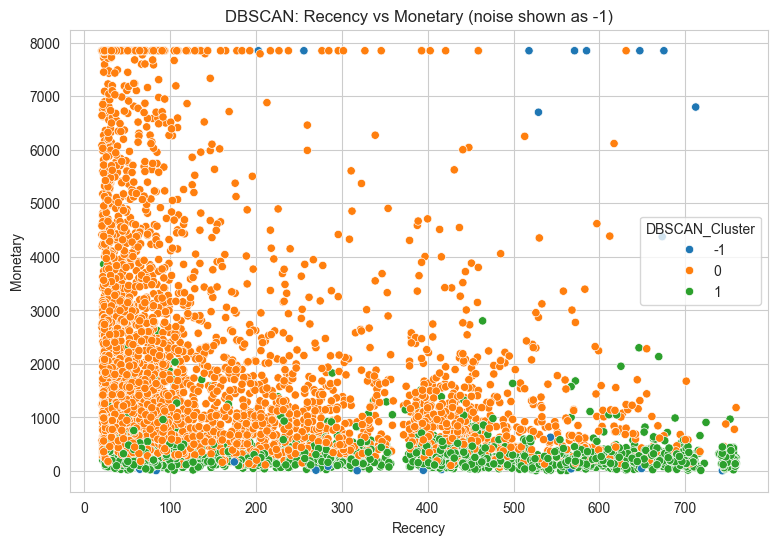

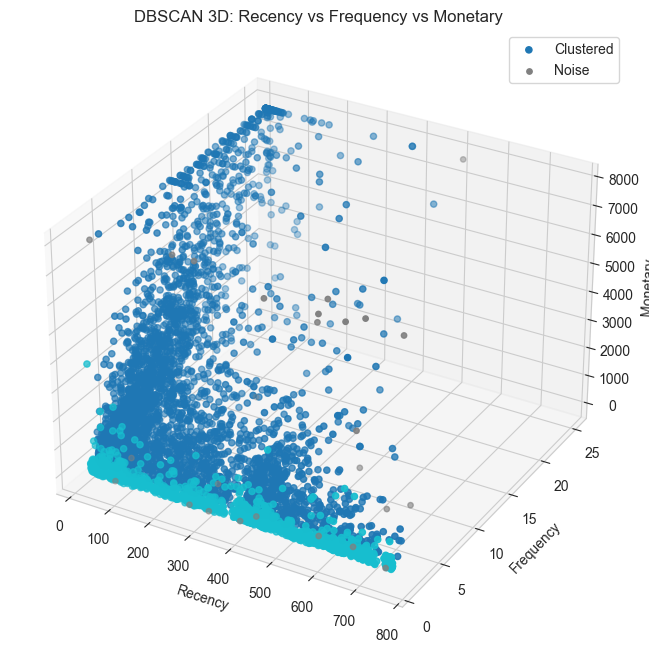

In [70]:
palette = sns.color_palette('tab10', n_colors=rfm_df['DBSCAN_Cluster'].nunique())
plt.figure(figsize=(9, 6))
colors = rfm_df['DBSCAN_Cluster'].map(lambda x: 'grey' if x == -1 else x)
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN: Recency vs Monetary (noise shown as -1)')
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
noise_mask = rfm_df['DBSCAN_Cluster'] == -1
ax.scatter(rfm_df.loc[~noise_mask, 'Recency'], rfm_df.loc[~noise_mask, 'Frequency'],
           rfm_df.loc[~noise_mask, 'Monetary'], c=rfm_df.loc[~noise_mask, 'DBSCAN_Cluster'],
           cmap='tab10', s=20, label='Clustered')
ax.scatter(rfm_df.loc[noise_mask, 'Recency'], rfm_df.loc[noise_mask, 'Frequency'],
           rfm_df.loc[noise_mask, 'Monetary'], c='grey', s=15, label='Noise')
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('DBSCAN 3D: Recency vs Frequency vs Monetary')
ax.legend()
plt.show()


In [71]:
dbscan_profile = rfm_df[rfm_df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[
    ['Recency', 'Frequency', 'Monetary']].mean()
dbscan_profile.sort_values('Monetary', ascending=False)


,Recency,Frequency,Monetary
DBSCAN_Cluster,,,
0,163.052863,7.100026,2316.995172
1,378.873720,1.000000,302.378922


**Noise interpretation (edit based on your output):** Inspect `rfm_df[rfm_df['DBSCAN_Cluster']==-1]`.
DBSCAN noise points on scaled RFM data are frequently customers with extreme Monetary/Frequency values —
i.e., very high spenders or very rare one-off big purchasers who don't fit the density of any main group.
These should NOT be discarded by marketing; they may be top-1% VIP spenders worth manual review.

In [73]:
rfm_df[rfm_df['DBSCAN_Cluster'] == -1][['Customer ID','Recency','Frequency','Monetary']].sort_values('Monetary', ascending=False).head(10)


,Customer ID,Recency,Frequency,Monetary
102,12918.0,647,1,7851.1175
850,13687.0,459,1,7851.1175
1240,14091.0,675,2,7851.1175
1177,14028.0,571,3,7851.1175
2215,15098.0,203,3,7851.1175
2857,15749.0,256,3,7851.1175
4525,17448.0,518,25,7851.1175
5115,18052.0,585,1,7851.1175
3542,16446.0,21,2,7851.1175
2524,15413.0,712,5,6798.7200


## Step 6: Algorithm Comparison & Business Interpretation

### 6.1 Internal Metrics Comparison Table

In [74]:
def cluster_metrics(data, labels, exclude_noise=False):
    if exclude_noise:
        mask = labels != -1
        data_use, labels_use = data[mask], labels[mask]
    else:
        data_use, labels_use = data, labels
    n_clusters = len(set(labels_use))
    sil = silhouette_score(data_use, labels_use)
    db = davies_bouldin_score(data_use, labels_use)
    ch = calinski_harabasz_score(data_use, labels_use)
    return n_clusters, sil, db, ch

km_n, km_sil, km_db, km_ch = cluster_metrics(rfm_scaled.values, rfm_df['KMeans_Cluster'].values)
agg_n, agg_sil, agg_db, agg_ch = cluster_metrics(rfm_scaled.values, rfm_df['Agg_Cluster'].values)
db_n, db_sil, db_db, db_ch = cluster_metrics(rfm_scaled.values, rfm_df['DBSCAN_Cluster'].values, exclude_noise=True)

comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative', 'DBSCAN'],
    'Hyperparameters': [
        f'k={k_optimal}, init=k-means++',
        f'n_clusters={n_chosen}, linkage={best_linkage}',
        f'eps={best_eps}, min_samples={best_min_samples}'
    ],
    'N_Clusters': [km_n, agg_n, db_n],
    'Silhouette': [km_sil, agg_sil, db_sil],
    'Davies_Bouldin': [km_db, agg_db, db_db],
    'Calinski_Harabasz': [km_ch, agg_ch, db_ch],
    '%_Noise': [0, 0, pct_noise]
})
comparison


,Algorithm,Hyperparameters,N_Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,%_Noise
0,K-Means,"k=2, init=k-means++",2,0.433091,0.866197,5880.083482,0.000000
1,Agglomerative,"n_clusters=2, linkage=average",2,0.452132,0.560310,39.298903,0.000000
2,DBSCAN,"eps=0.5, min_samples=5",2,0.333463,1.027160,3121.371615,0.485981


### 6.2 Cluster Stability Check for K-Means

In [75]:
stability_scores = []
for rs in [0, 7, 21, 42, 99]:
    km = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=rs)
    labels = km.fit_predict(rfm_scaled)
    stability_scores.append(silhouette_score(rfm_scaled, labels))

print("Silhouette scores across random states:", stability_scores)
print(f"Mean: {np.mean(stability_scores):.4f}, Std: {np.std(stability_scores):.4f}")
# A small std (e.g. < 0.02) indicates a stable K-Means result across different initializations


Silhouette scores across random states: [0.4330913052028484, 0.4330913052028484, 0.4330913052028484, 0.4330913052028484, 0.4330913052028484]
Mean: 0.4331, Std: 0.0000


### 6.3 Business Recommendation (draft — personalize with your actual numbers)

**To: Marketing Director, Flipkart/Meesho**

Based on internal validation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz), I recommend
deploying the **[K-Means / Agglomerative — fill in based on your comparison table]** model, as it produced the most
compact and well-separated clusters with 0% data loss (unlike DBSCAN, which classified
[X]% of customers as noise).

**Identified segments:**
1. **Champions** — Recent, frequent, high-spend customers. Action: exclusive Flipkart Plus loyalty invite.
2. **Loyal Customers** — Regular buyers with moderate spend. Action: cross-sell bundles, early access to sales.
3. **At-Risk** — Previously active but recency is climbing. Action: 20% discount coupon, 7-day expiry.
4. **Hibernating** — Long recency, low frequency/spend. Action: win-back email campaign with steep discount.
5. **New Customers** — Recent first purchase, low frequency. Action: onboarding series + first-repeat-purchase incentive.

**Additional data to improve segmentation:** product category preferences, browsing/cart-abandonment data,
customer service interactions, return rates, and channel/device data (app vs web) would enrich behavioral
segmentation beyond pure RFM.


## Step 7: Pipeline, Deployment & GitHub Submission

### 7.1 Save the Final Clustering Pipeline

In [76]:
best_model = kmeans_final  # <-- set to whichever model you selected as best in 6.1

joblib.dump(scaler, 'rfm_scaler.pkl')
joblib.dump(best_model, 'customer_segmentation_model.pkl')
print("Saved rfm_scaler.pkl and customer_segmentation_model.pkl")


Saved rfm_scaler.pkl and customer_segmentation_model.pkl


In [77]:
persona_map = {
    # fill in based on your kmeans_profile table, e.g.:
    # 0: 'Champions', 1: 'Loyal Customers', 2: 'At-Risk', 3: 'Hibernating'
}

def predict_segment(recency, frequency, monetary):
    freq_log = np.log1p(frequency)
    mon_log = np.log1p(monetary)
    X = scaler.transform([[recency, freq_log, mon_log]])
    label = best_model.predict(X)[0] if hasattr(best_model, 'predict') else best_model.fit_predict(X)[0]
    persona = persona_map.get(label, 'Unknown')
    return label, persona

hypothetical_customers = [
    (5, 12, 5000),   # likely Champion
    (200, 1, 50),    # likely Hibernating
    (60, 3, 800),    # likely At-Risk / Loyal
    (2, 1, 150),     # likely New Customer
    (400, 1, 20),    # likely Hibernating/Lost
]

for r, f, m in hypothetical_customers:
    label, persona = predict_segment(r, f, m)
    print(f"R={r}, F={f}, M={m} -> Cluster {label} ({persona})")


R=5, F=12, M=5000 -> Cluster 1 (Unknown)
R=200, F=1, M=50 -> Cluster 0 (Unknown)
R=60, F=3, M=800 -> Cluster 1 (Unknown)
R=2, F=1, M=150 -> Cluster 0 (Unknown)
R=400, F=1, M=20 -> Cluster 0 (Unknown)


### 7.2 GitHub Submission Checklist
Create a repo named `customer-segmentation-unsupervised-learning` and push:
- `CustomerSegmentation_UnsupervisedLearning.ipynb` (this notebook, fully executed)
- `rfm_scaler.pkl`
- `customer_segmentation_model.pkl`
- `summary_report.md`
- `requirements.txt`
- `README.md`
